# Preprocessing Pipeline Design & Structural Conditioning

This notebook explores the operational and statistical trade-offs behind the data engineering choices for the MeteoNet precipitation radar dataset. 

When working with large spatiotemporal datasets, raw data arrays must be structurally conditioned before being passed into deep learning optimization layers. To achieve stable model training on an NVIDIA CUDA GPU, the preprocessing pipeline must balance computational efficiency with the preservation of high-frequency weather features.

### Core Engineering Objectives:
1. **Geometric Dimensionality Reduction**: Downsample data arrays using area-relation interpolation (`cv2.INTER_AREA`) to minimize GPU memory footprints while preserving rain-band structures, and map binary flags using nearest-neighbor interpolation (`cv2.INTER_NEAREST`) to prevent boundary artifacts.
2. **Outlier Mitigation**: Define a realistic physical clipping ceiling ($1500$) to cap unrepresentative, explosive power-law convective peaks before spatial downsampling, protecting downsampled cells from being artificially inflated.
3. **Array Linearization & Regularization**: Implement a global logarithmic transform ($\log_{1p}$) to linearize the severe heavy-tailed precipitation distribution, improving gradient flow and preventing gradient compression in deep neural networks.
4. **Data Isolation Frameworks**: Track invalid sensor pixels (`-1`) into parallel binary validity masks to eliminate label noise during backpropagation.
5. **Temporal Interruption Filtering**: Establish chronological sequence verification algorithms to isolate continuous 5-minute tracking series.

The experiments documented in this notebook provide the technical foundation for the production pipeline script implemented in `src/data/preprocess.py`.


In [1]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

# Standardize plotting configurations
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "turbo"


In [2]:
# Configure target domain matrix parameters
zone = "NW"
year = 2017
month = 1
part_month = 1  # Each month is divided into 3 continuous segments on disk

# Assemble repository-compliant directory variables
directory = "../data/raw/"
directory_data = directory + f"{zone}_rainfall_{str(year)}/rainfall-{zone}-{str(year)}-{str(month).zfill(2)}/"
fname = directory_data + f"rainfall_{zone}_{str(year)}_{str(month).zfill(2)}.{str(part_month)}.npz"
fname_coords = directory + f"radar_coords_{zone}.npz"

print(f"Loading data archive: {Path(fname).name}")
print(f"Loading coordinate map: {Path(fname_coords).name}")


Loading data archive: rainfall_NW_2017_01.1.npz
Loading coordinate map: radar_coords_NW.npz


In [3]:
# Ingest raw arrays from compressed NumPy storage
d = np.load(fname, allow_pickle=True)
data = d['data']
dates = d['dates']
miss_dates = d['miss_dates']

coords = np.load(fname_coords, allow_pickle=True)
lat = coords['lats']
lon = coords['lons']

print("Data arrays successfully loaded into memory cache.")


Data arrays successfully loaded into memory cache.


## 1. Geometric Interpolation Analysis (Resolution Optimization)

The raw Météo-France radar scans possess high native spatial dimensions. As input image resolution scales upward, the computational complexity and GPU VRAM footprint of convolutional encoder-decoder models scale quadratically. 

The following experiment evaluates the visual impact of area-relation interpolation (`cv2.INTER_AREA`), which averages pixel neighborhoods to downsample the arrays without discarding localized convective storm cores.


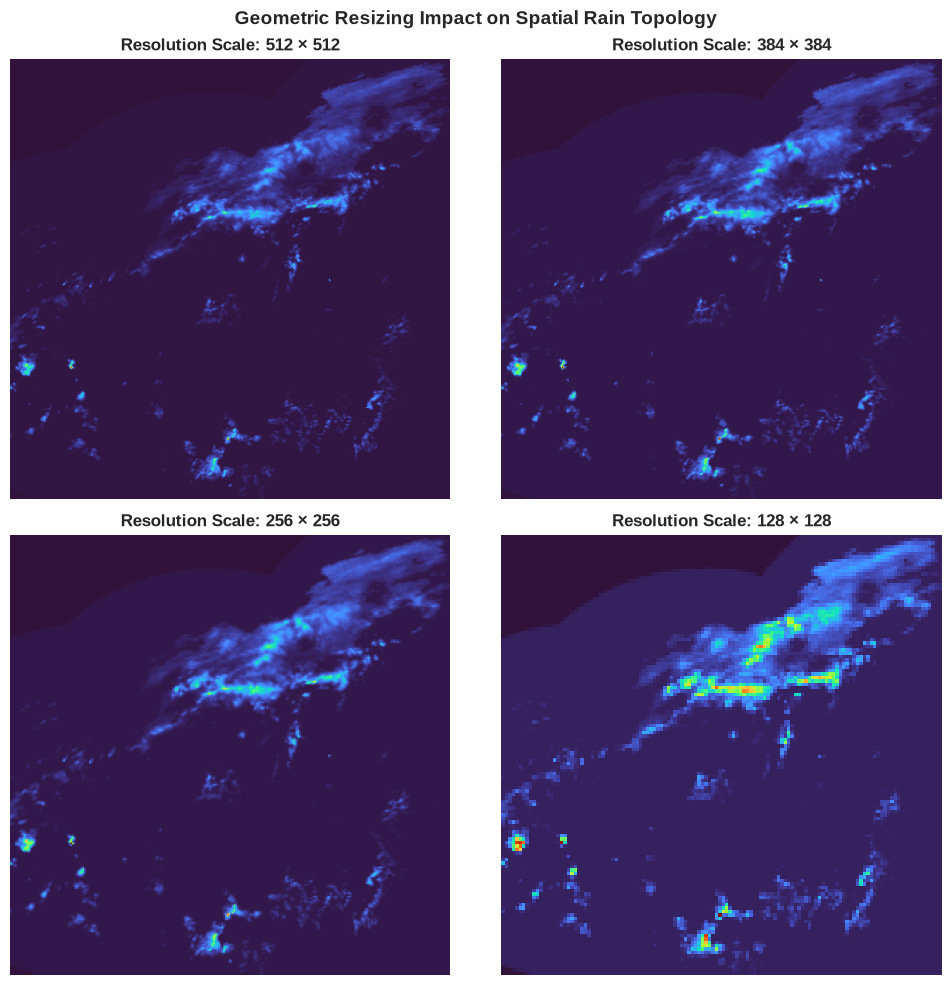

In [4]:
# Extract a representative 2D frame and cast to standard float32
single_2d_frame = data[256].astype(np.float32)

sizes = [512, 384, 256, 128]
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

for axis, size in zip(ax.ravel(), sizes):
    target_dsize = (int(size), int(size))
    
    resized = cv2.resize(
        single_2d_frame, 
        target_dsize, 
        interpolation=cv2.INTER_AREA
    )
    
    axis.imshow(resized)
    axis.set_title(f"Resolution Scale: {size} × {size}", fontsize=12, weight="bold")
    axis.axis("off")

plt.suptitle("Geometric Resizing Impact on Spatial Rain Topology", fontsize=14, weight="bold", y=0.98)
plt.tight_layout()
plt.show()


In [5]:
original_pixels = single_2d_frame.size
print(f"Native Grid Resolution: {single_2d_frame.shape} ({original_pixels:,} total pixels)")
print("-" * 55)

for size in sizes:
    pixels = size * size
    reduction = original_pixels / pixels
    print(f" -> Targeted {size:3d}x{size:3d} Grid | Dimension Reduction: {reduction:.1f}x fewer pixels")


Native Grid Resolution: (565, 784) (442,960 total pixels)
-------------------------------------------------------
 -> Targeted 512x512 Grid | Dimension Reduction: 1.7x fewer pixels
 -> Targeted 384x384 Grid | Dimension Reduction: 3.0x fewer pixels
 -> Targeted 256x256 Grid | Dimension Reduction: 6.8x fewer pixels
 -> Targeted 128x128 Grid | Dimension Reduction: 27.0x fewer pixels


> **Downstream Preprocessing Decision**: A spatial resolution of **256 × 256** shrinks the global pixel burden by approximately **6.8x**, significantly accelerating backpropagation and training runtimes, while maintaining most relevant details. Crucially, area interpolation (`cv2.INTER_AREA`) averages localized pixel neighborhoods. This is mathematically essential for downsampling continuous physical variables, as it preserves the macro-scale shapes and continuity of localized weather fronts without introducing aliasing artifacts.


## 2. Rainfall Intensity Clipping Boundaries

Precipitation datasets follow an extreme, heavy-tailed power-law distribution. Rare, explosive convective storm cells occupy a tiny fraction of total pixels but generate extreme values that skew the numeric range, risking gradient destabilization during optimization. 

To protect the spatial downsampling step, a hard clip is applied at a ceiling of **1500**. If spatial reduction (`cv2.INTER_AREA`) is performed before clipping, extreme outlier pixels would bleed into surrounding cells via neighborhood averaging, artificially expanding the footprint of unrepresentative peaks. Clipping first prevents this artifact.


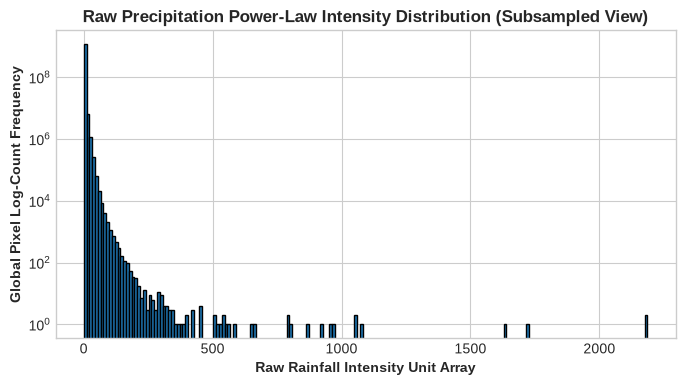

In [6]:
# Process a downsampled view
subsampled_view = data[2:, :, :]
clean_values = subsampled_view[subsampled_view >= 0]

plt.figure(figsize=(8, 4))
plt.hist(clean_values, bins=200, color="tab:blue", edgecolor="black", log=True)
plt.xlabel("Raw Rainfall Intensity Unit Array", weight="bold")
plt.ylabel("Global Pixel Log-Count Frequency", weight="bold")
plt.title("Raw Precipitation Power-Law Intensity Distribution (Subsampled View)", weight="bold")
plt.show()


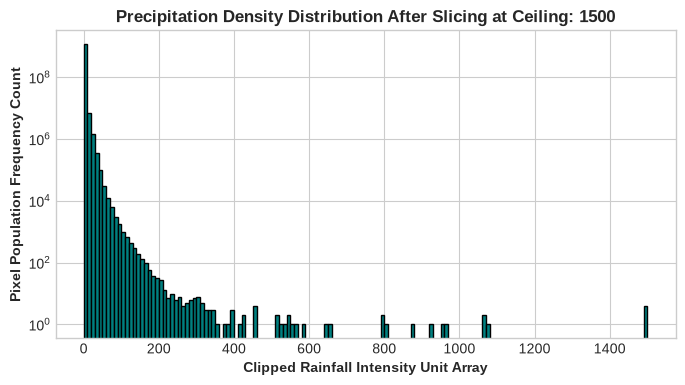

In [7]:
clip_value = 1500
clipped = np.clip(clean_values, 0, clip_value)

plt.figure(figsize=(8, 4))
plt.hist(clipped, bins=150, color="teal", edgecolor="black", log=True)
plt.xlabel("Clipped Rainfall Intensity Unit Array", weight="bold")
plt.ylabel("Pixel Population Frequency Count", weight="bold")
plt.title(f"Precipitation Density Distribution After Slicing at Ceiling: {clip_value}", weight="bold")
plt.show()


In [8]:
print(f"Absolute Peak Intensity Before Clipping : {clean_values.max():.2f} (10⁻² mm)")
print(f"Absolute Peak Intensity After Clipping  : {clipped.max():.2f} (10⁻² mm)")


Absolute Peak Intensity Before Clipping : 2186.00 (10⁻² mm)
Absolute Peak Intensity After Clipping  : 1500.00 (10⁻² mm)


> **Preprocessing Decision**: Enforcing a hard threshold ceiling cap at **1500** suppresses extreme, anomalous convective spikes that destabilize batch normalization layers, while preserving the physical range of realistic heavy rainfall events.


## 3. Logarithmic Scaling Transformation

In precipitation datasets, the vast majority of pixels represent zero or trace rainfall, while high-intensity rain events are sparse but statistically critical. Standard Min-Max normalization compresses these vital high-intensity structures into a tiny numerical band near zero, starving neural network gradients.

To solve this, a **Logarithmic Transformation** is implemented using $f(x) = \frac{\log(1 + x)}{\log(1 + \text{clip\_value})}$. The $\log_{1p}$ function stretches out low-to-medium rainfall ranges while squashing extreme values, linearizing the heavy-tailed distribution to guarantee smooth backpropagation and high-fidelity tracking.


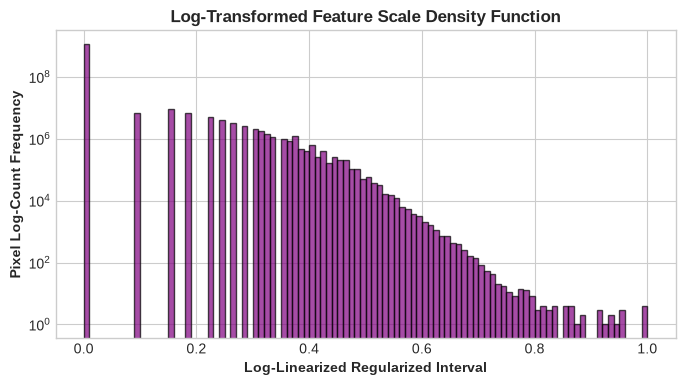

In [9]:
# Apply global log transform to the clipped subsampled array
global_log_max = np.log1p(clip_value)
log_transformed = np.log1p(clipped) / global_log_max

plt.figure(figsize=(8, 4))
plt.hist(log_transformed, bins=100, color="purple", edgecolor="black", alpha=0.7, log=True)
plt.xlabel("Log-Linearized Regularized Interval", weight="bold")
plt.ylabel("Pixel Log-Count Frequency", weight="bold")
plt.title("Log-Transformed Feature Scale Density Function", weight="bold")
plt.show()


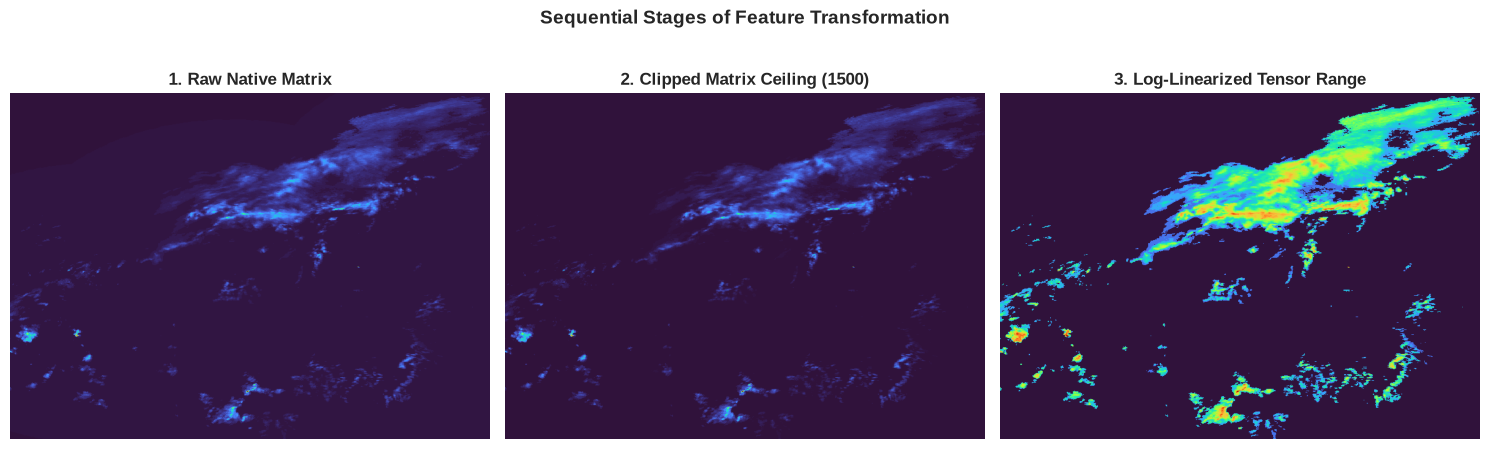

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(single_2d_frame)
ax[0].set_title("1. Raw Native Matrix", weight="bold")

ax[1].imshow(np.clip(single_2d_frame, 0, clip_value))
ax[1].set_title(f"2. Clipped Matrix Ceiling ({clip_value})", weight="bold")

ax[2].imshow(np.log1p(np.clip(single_2d_frame, 0, clip_value)) / global_log_max)
ax[2].set_title("3. Log-Linearized Tensor Range", weight="bold")

for a in ax:
    a.axis("off")

plt.suptitle("Sequential Stages of Feature Transformation", fontsize=14, weight="bold", y=0.98)
plt.tight_layout()
plt.show()


## 4. Sensor Gaps & Parallel Validity Mask Extraction

Geographic missing measurements are flagged by a distinct negative integer value of **-1**. If these blind spots are blindly converted to zero or processed through neighborhood-averaging interpolation (`cv2.INTER_AREA`), the missing flags will contaminate valid adjacent precipitation data.

To prevent this, a strict binary validity mask (`frame != -1`) is extracted *before* applying any transformations. To ensure boundaries remain completely binary (without fractional interpolation blur), the validity mask is downsampled using nearest-neighbor interpolation (`cv2.INTER_NEAREST`).


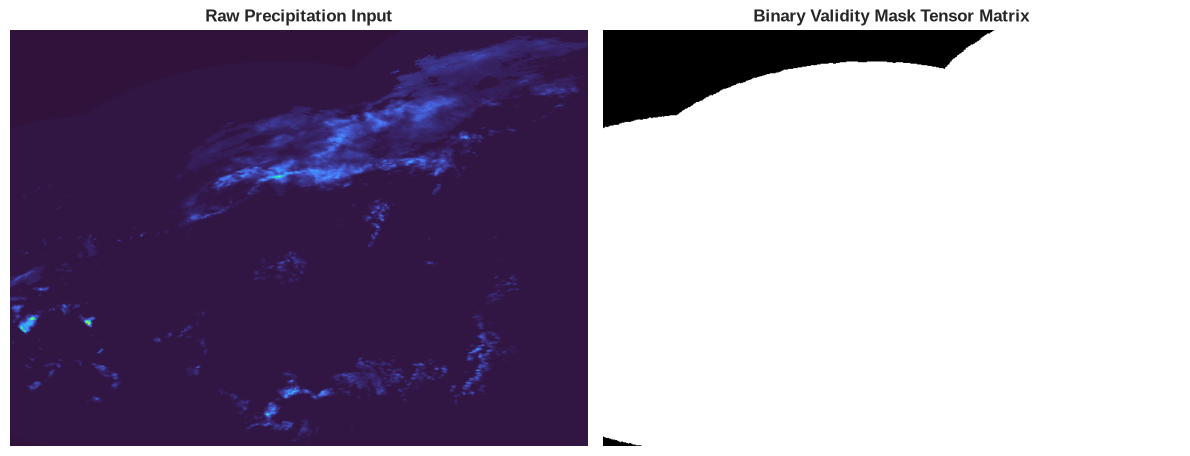

In [11]:
frame_sample = data[250]
validity_mask = (frame_sample != -1).astype(bool)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(frame_sample)
ax[0].set_title("Raw Precipitation Input", weight="bold")

ax[1].imshow(validity_mask, cmap="gray")
ax[1].set_title("Binary Validity Mask Tensor Matrix", weight="bold")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()


In [12]:
valid_fraction = validity_mask.mean()
print(f"Total Geographically Available Pixel Coverage: {100 * valid_fraction:.2f}%")
print(f"Total Obscured Geographic Missing Field Void : {100 * (1.0 - valid_fraction):.2f}%")


Total Geographically Available Pixel Coverage: 91.85%
Total Obscured Geographic Missing Field Void : 8.15%


## 5. Temporal Interruption Verification Loop

Spatiotemporal models require unbroken radar sequence segments to compute atmospheric velocity trends. Complete timeline data skips break temporal continuity and distort velocity calculations. 

The standard sampling interval is exactly **5 minutes**. Gaps larger than 5 minutes represent an operational outage, requiring the sequence generator to discard the affected forecast window.


Unique Time Deltas Detected Across Archive Sequence Rows:
-----------------------------------------------------------------
Delta: 300000000 microseconds (   5 Minutes) | Population Count: 2879


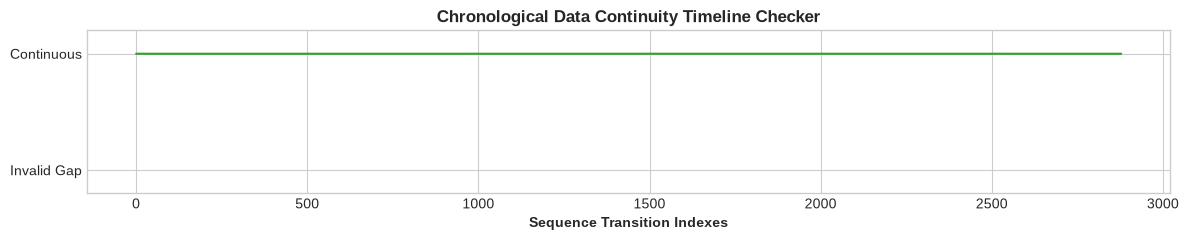

In [13]:
# Evaluate interval deltas across adjacent frames
expected_delta = np.timedelta64(5, "m")

# Handle string-to-datetime parsing explicitly if required by array format
if not isinstance(dates, np.datetime64):
    clean_dates = np.array([np.datetime64(d) for d in dates])
else:
    clean_dates = dates

time_deltas = np.diff(clean_dates)

# Evaluate if transitions match our strict 5-minute sampling interval
valid_transitions = time_deltas == expected_delta

plt.figure(figsize=(12, 2.5))
plt.plot(valid_transitions.astype(int), color="tab:green", linewidth=1.5)

# Calculate unique step deltas safely using standard datetime calculations
unique_intervals, population_counts = np.unique(time_deltas, return_counts=True)
print("Unique Time Deltas Detected Across Archive Sequence Rows:")
print("-" * 65)
for interval, count in zip(unique_intervals, population_counts):
    if hasattr(interval, "total_seconds"):
        minutes_val = int(interval.total_seconds() // 60)
    else:
        minutes_val = int(interval.astype("timedelta64[m]").astype(int))
    print(f"Delta: {str(interval):<15} ({minutes_val:>4} Minutes) | Population Count: {count}")

plt.yticks([0, 1], ["Invalid Gap", "Continuous"])
plt.ylim(-0.2, 1.2)
plt.title("Chronological Data Continuity Timeline Checker", weight="bold")
plt.xlabel("Sequence Transition Indexes", weight="bold")
plt.tight_layout()
plt.show()


In [14]:
invalid_indices = np.where(~valid_transitions)[0]
print(f"Total Chronological Sequence Timeline Gaps Detected: {len(invalid_indices)}")


Total Chronological Sequence Timeline Gaps Detected: 0


In [15]:
# Simulating the window sequence verification algorithm
sequence_length = 6
predict_steps = 6

discarded_sequences = 0
usable_sequences = 0

for start in range(len(clean_dates) - sequence_length - predict_steps):
    seq_window = clean_dates[start : start + sequence_length + predict_steps]
    is_window_valid = True
    
    for i in range(len(seq_window) - 1):
        if seq_window[i+1] - seq_window[i] != expected_delta:
            is_window_valid = False
            break
            
    if is_window_valid:
        usable_sequences += 1
    else:
        discarded_sequences += 1

print(f"Total Evaluated Forecast Windows : {usable_sequences + discarded_sequences}")
print(f" -> Total Usable Sequence Blocks : {usable_sequences}")
print(f" -> Total Discarded Gapped Voids : {discarded_sequences}")


Total Evaluated Forecast Windows : 2868
 -> Total Usable Sequence Blocks : 2868
 -> Total Discarded Gapped Voids : 0


## 6. Infrastructure Compute & Storage Scaling Estimates

To plan infrastructure storage targets, we estimate the file footprint of our float32 multi-step tensor blocks across different grid dimensions.


In [16]:
target_resolutions = [512, 384, 256, 128]
total_frames = data.shape[0]

print(f"Evaluating Storage Scaling for {total_frames} Sequential Radar Frames:")
print("-" * 75)
for res in target_resolutions:
    # Estimate total size in Gigabytes assuming float32 precision parameters (4 bytes)
    archive_gb = (total_frames * res * res * 4) / (1024.0 ** 3)
    print(f" -> Shape {res:3d}x{res:3d} : {archive_gb:.2f} GB per segment container | ~{3.0 * archive_gb:.2f} GB per complete month block")


Evaluating Storage Scaling for 2880 Sequential Radar Frames:
---------------------------------------------------------------------------
 -> Shape 512x512 : 2.81 GB per segment container | ~8.44 GB per complete month block
 -> Shape 384x384 : 1.58 GB per segment container | ~4.75 GB per complete month block
 -> Shape 256x256 : 0.70 GB per segment container | ~2.11 GB per complete month block
 -> Shape 128x128 : 0.18 GB per segment container | ~0.53 GB per complete month block


## 7. Operational Preprocessing Pipelines Functional Logic

Structural conditioning algorithms are bundled inside modular pipeline routines. Production script logic is mirrored by these functional modules, ensuring memory efficiency through the execution of array conversions, hard-clipping, dual-mode downsampling, and global logarithmic transformation sequence steps.


In [17]:
def resize_array(array, target_height, target_width):
    """Downsamples features using neighborhood averaging for continuous fields."""
    return cv2.resize(
        array.astype(np.float32),
        (target_width, target_height),
        interpolation=cv2.INTER_AREA
    )


def resize_mask(mask, target_height, target_width):
    """Downsamples validity masks using nearest-neighbor to retain binary values."""
    return cv2.resize(
        mask.astype(np.float32),
        (target_width, target_height),
        interpolation=cv2.INTER_NEAREST
    ).astype(bool)


def preprocess_frame(frame, clip_value=1500, resize_height=256, resize_width=256):
    """
    Applies the full preprocessing chain to a single radar frame:
    Extracts the mask, clips outliers, resizes spatially, and log-normalizes.
    """
    # Track missing data mask (-1 values) before making structural changes
    mask = (frame != -1).astype(bool)
    frame = frame.astype(np.float32)
    
    # Hard clip the continuous data first to protect upcoming INTER_AREA interpolation
    frame = np.clip(frame, 0, clip_value)

    # Scale spatial matrix geometries using their respective interpolation algorithms
    frame = resize_array(frame, resize_height, resize_width)
    mask = resize_mask(mask, resize_height, resize_width)

    # Apply Logarithmic Transformation to linearize the power-law distribution
    global_log_max = np.log1p(clip_value)  
    frame = np.log1p(frame) / global_log_max

    return frame, mask


In [18]:
num_frames = len(data)
target_shape = (256, 256)

# Pre-allocate blocks of memory upfront to optimize operational VRAM/RAM footprints
processed_data = np.empty((num_frames, *target_shape), dtype=np.float32)
processed_masks = np.empty((num_frames, *target_shape), dtype=bool)

# Populate the pre-allocated arrays frame-by-frame
for i in range(num_frames):
    frame_perf, mask_perf = preprocess_frame(
        frame=data[i], 
        clip_value=1500, 
        resize_height=target_shape[0], 
        resize_width=target_shape[1]
    )
    processed_data[i] = frame_perf
    processed_masks[i] = mask_perf

# Coordinate resizing using area interpolation for continuous geographic coordinates
lat_resized = cv2.resize(lat.astype(np.float32), target_shape, interpolation=cv2.INTER_AREA)
lon_resized = cv2.resize(lon.astype(np.float32), target_shape, interpolation=cv2.INTER_AREA)

print(f"Preprocessed Data Matrix Shape    : {processed_data.shape}")
print(f"Preprocessed Mask Matrix Shape    : {processed_masks.shape}")
print(f"Downsampled Latitude Coordinates  : {lat_resized.shape}")
print(f"Downsampled Longitude Coordinates : {lon_resized.shape}")


Preprocessed Data Matrix Shape    : (2880, 256, 256)
Preprocessed Mask Matrix Shape    : (2880, 256, 256)
Downsampled Latitude Coordinates  : (256, 256)
Downsampled Longitude Coordinates : (256, 256)


## 8. Geospatial Visualization & Coastline Alignment Verification

To confirm that the spatial grid transformations and coordinate downsampling arrays match absolute geographic coordinate systems correctly, the preprocessed outputs are plotted using Cartopy. This ensures sub-pixel alignment against the vector coastlines of France before export.


Rainfall Matrix Dimensions : (2880, 256, 256)
Latitude Bounding Vector   : (256, 256)
Longitude Bounding Vector  : (256, 256)


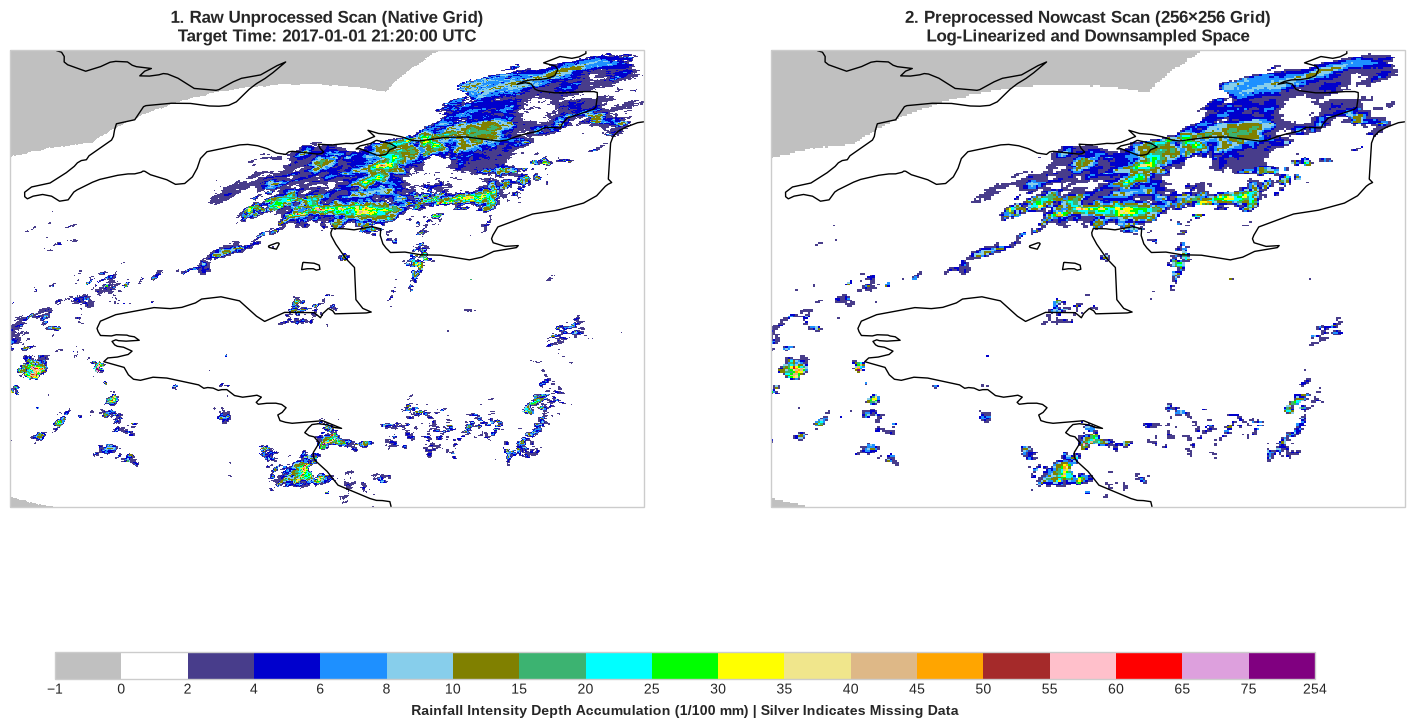

In [19]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Re-verify matching resolution matrices
print(f"Rainfall Matrix Dimensions : {processed_data.shape}")
print(f"Latitude Bounding Vector   : {lat_resized.shape}")
print(f"Longitude Bounding Vector  : {lon_resized.shape}")

sample_idx = 256

# --- 1. PREPARE PREPROCESSED DATA FOR PLOTTING ---
mask_resized = processed_masks[sample_idx]
global_log_max = np.log1p(1500)
# Reverse the log transformation back to raw intensity depth units
plot_array_prep = np.expm1(processed_data[sample_idx] * global_log_max)
# Force all invalid pixel coordinates to -1.0 for the colormap boundary rule
plot_array_prep[~mask_resized] = -1.0

# --- 2. PREPARE RAW DATA FOR PLOTTING ---
# Extract raw frame and create native resolution mask from raw -1 indices
raw_frame = data[sample_idx].astype(np.float32)
raw_mask = (raw_frame != -1)
plot_array_raw = raw_frame.copy()
plot_array_raw[~raw_mask] = -1.0

# --- 3. COLORMAP & BOUNDARY CONFIGURATIONS ---
rainfall_cmap = colors.ListedColormap([
    "silver", "white", "darkslateblue", "mediumblue", "dodgerblue", "skyblue",
    "olive", "mediumseagreen", "cyan", "lime", "yellow", "khaki", "burlywood",
    "orange", "brown", "pink", "red", "plum", "purple"
])
rainfall_bounds = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 75, 254]
rainfall_norm = colors.BoundaryNorm(rainfall_bounds, rainfall_cmap.N)

# Set spatial bounding box based on native coordinate limits (shared extent)
extent_box = [lon.min(), lon.max(), lat.min(), lat.max()]

fig, (ax1, ax2) = plt.subplots(
    1, 2, 
    figsize=(18, 9), 
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot Raw Frame
mesh_raw = ax1.pcolormesh(
    lon, lat, plot_array_raw,
    cmap=rainfall_cmap, norm=rainfall_norm, shading='auto', transform=ccrs.PlateCarree()
)
ax1.coastlines(resolution='50m', linewidth=1.0, color="black")
ax1.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.6, linestyle=":")
ax1.set_extent(extent_box)
ax1.set_title(f"1. Raw Unprocessed Scan (Native Grid)\nTarget Time: {dates[sample_idx]} UTC", fontsize=12, weight="bold")
ax1.set_xlabel("Longitude Coordinates")
ax1.set_ylabel("Latitude Coordinates")

# Plot Preprocessed and Downsampled Frame
mesh_prep = ax2.pcolormesh(
    lon_resized, lat_resized, plot_array_prep,
    cmap=rainfall_cmap, norm=rainfall_norm, shading='auto', transform=ccrs.PlateCarree()
)
ax2.coastlines(resolution='50m', linewidth=1.0, color="black")
ax2.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.6, linestyle=":")
ax2.set_extent(extent_box)
ax2.set_title(f"2. Preprocessed Nowcast Scan ({target_shape[0]}×{target_shape[1]} Grid)\nLog-Linearized and Downsampled Space", fontsize=12, weight="bold")
ax2.set_xlabel("Longitude Coordinates")

# Standardize aspect ratios across both geospatial reference projections
ax1.set_aspect('equal', adjustable='box')
ax2.set_aspect('equal', adjustable='box')

# Add a shared horizontal colorbar positioned beneath both subplots
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
cbar = fig.colorbar(mesh_prep, cax=cbar_ax, boundaries=rainfall_bounds, ticks=rainfall_bounds, orientation='horizontal')
cbar.set_label('Rainfall Intensity Depth Accumulation (1/100 mm) | Silver Indicates Missing Data', weight="bold", labelpad=6)

plt.show()


>  Some details are lost during preprocessing, however all major and most minor structures stay intact. The preprocessed frame shows a mostly accurate representation of the original frame, which is a worthwhile trade-off considering the performance gains.

## Final Preprocessing Pipeline & Executive Summary

The experiments documented in this design notebook establish the automated preprocessing architecture. By chaining these distinct matrix operations sequentially, raw sensor files are mapped into clean deep learning variables.

### Summary of Core Empirical Observations:
* **5-Minute Sampling Interval**: Nominal radar scans occur exactly every 5 minutes. Any temporal interval delta larger than 5 minutes signifies an operational scan outage.
* **Temporal Discontinuities**: Missing radar scans occasionally interrupt chronological sequence rows. Because predictive spatiotemporal models require continuous history tracking, any time gap will distort acceleration vectors.
* **Systematic Spatial Outages**: Invalid spatial measurements are explicitly encoded via native -1 flag matrices. These are not random pixel noise; they map to fixed geographic boundaries (terrain blockages).
* **Extreme Power-Law Skew**: The distribution of rainfall is heavily skewed toward zero, but features a minute fraction of extreme convective rain values that create long-tailed behavior.
* **High Spatial Dimensions**: The original radar images are sufficiently large that training directly on them introduces heavy computational and GPU VRAM scaling overhead.

### Data-Driven Preprocessing Architecture & Strategies:
1. **Geometric Interpolation (`resize_array` / `resize_mask`)**: Spatial dimensions are downsampled to a unified 256 x 256 footprint. Area-averaging logic (`cv2.INTER_AREA`) is used for radar values to preserve shapes, while nearest-neighbor interpolation (`cv2.INTER_NEAREST`) is applied to binary validity masks to prevent boundary bleeding.
2. **Extreme Outlier Slicing (`clip_value: 1500`)**: A hard threshold ceiling is enforced *before* downsampling to suppress extreme, anomalous convective spikes. This prevents localized anomalies from skewing surrounding grids during interpolation.
3. **Logarithmic Scaling Transformation**: Raw precipitation inputs are linearized using a global $\log_{1p}$ scale normalized against the maximum clipped range. Based on observations and distribution plots from the previous notebook `01_data_exploration.ipynb`, a log transform is ideal for this highly tail-ended radar data where most values sit at or close to 0. It creates a much more uniform distribution without relying on a super harsh cutoff (like capping everything at 100), ensuring that extreme weather events stay fully relevant for model training while preventing gradient compression.
4. **Parallel Validity Mask Extraction**: Spatial -1 flag grids are tracked into parallel binary validity masks. These can be passed directly to custom loss functions (`MaskedMSELoss`) to mask out gradients from missing regions, preventing sensor gaps from introducing label noise.
5. **Strict Temporal Sequence Filtering**: The sequence generator is configured to strictly discard any input-target loop sequence that contains an internal delta step gap larger than 5 minutes, guaranteeing clean temporal data continuity.

The final implementations of steps 1 through 4 are encoded in `src/data/preprocess.py` and automated completely via the command `make preprocess`. The implementation of step 5 is encoded in the (`RadarDataset`) class in `src/data/dataset.py`.
